<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/galaxy_formation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Simulating Galaxy Formation**

In [ ]:
!pip install scipy matplotlib -q

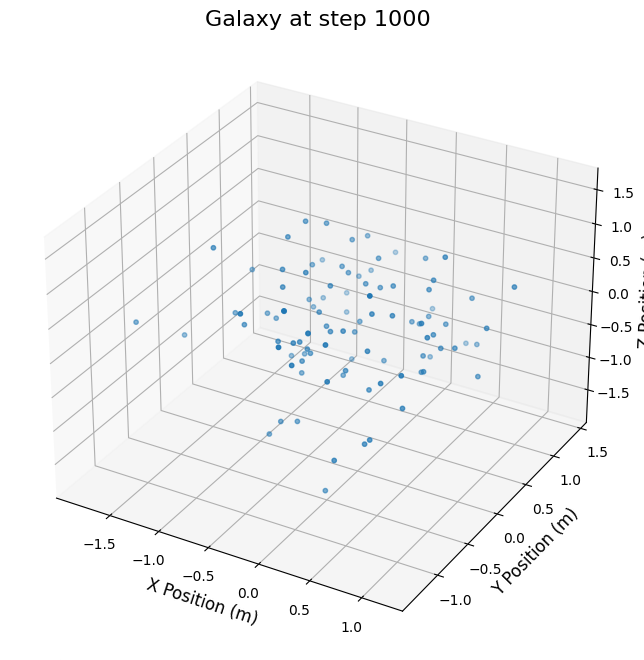

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Constants

# Gravitational constant, m^3 kg^-1 s^-2 | force between each pair of particles is calculated using Newton's gravitational law
G = 6.67430e-11

M_sun = 1.989e30  # Mass of the sun, kg
parsec = 3.086e16  # 1 parsec in meters
year = 3.154e7  # 1 year in seconds

# Number of particles (stars)
N = 100

# Randomly initialize positions (within a disk-like region) and velocities of the particles
def initialize_galaxy(N, disk_radius, velocity_dispersion):
    positions = np.random.randn(N, 3) * disk_radius * parsec
    velocities = np.random.randn(N, 3) * velocity_dispersion * 1000  # Convert to m/s
    masses = np.ones(N) * M_sun  # Assume each star has mass of one sun
    return positions, velocities, masses

# Function to compute gravitational acceleration on each particle
def acceleration(positions, masses):
    N = len(positions)
    acc = np.zeros((N, 3))
    for i in range(N):
        for j in range(N):
            if i != j:
                r_vec = positions[j] - positions[i]
                # Manuelle Berechnung der Norm
                r_mag_squared = r_vec[0]**2 + r_vec[1]**2 + r_vec[2]**2
                if r_mag_squared != 0:
                    r_mag = np.sqrt(r_mag_squared)
                    acc[i] += G * masses[j] * r_vec / r_mag_squared / r_mag
    return acc

# Time derivative function for the system (used in the ODE solver)
def derivatives(y, t, N, masses):
    positions = y[:3 * N].reshape((N, 3))
    velocities = y[3 * N:].reshape((N, 3))

    d_pos_dt = velocities
    d_vel_dt = acceleration(positions, masses)

    return np.concatenate((d_pos_dt.flatten(), d_vel_dt.flatten()))

# Function to simulate galaxy evolution
def simulate_galaxy(positions, velocities, masses, time_span, num_steps):
    N = len(positions)

    # Flatten initial conditions
    initial_conditions = np.concatenate((positions.flatten(), velocities.flatten()))

    # Time points for simulation
    time_points = np.linspace(0, time_span, num_steps)

    # Solve the system using odeint (integrating the differential equations)
    solution = odeint(derivatives, initial_conditions, time_points, args=(N, masses))

    # Extract the positions and velocities over time
    positions_over_time = solution[:, :3 * N].reshape((-1, N, 3))
    return positions_over_time


def plot_galaxy(positions, step):
    fig = plt.figure(figsize=(10, 8))  # Set figsize to make the plot larger
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], s=10)
    ax.set_title(f"Galaxy at step {step}", fontsize=16)  # Increased title font size
    ax.set_xlabel('X Position (m)', fontsize=12)
    ax.set_ylabel('Y Position (m)', fontsize=12)
    ax.set_zlabel('Z Position (m)', fontsize=12)

    plt.show()

# Initialize the galaxy
disk_radius = 10  # in parsecs
velocity_dispersion = 20  # km/s

positions, velocities, masses = initialize_galaxy(N, disk_radius, velocity_dispersion)

# Simulate the galaxy formation for 1 billion years with 1000 steps
time_span = 1e9 * year  # 1 billion years
num_steps = 1000

positions_over_time = simulate_galaxy(positions, velocities, masses, time_span, num_steps)

# Visualize the final state of the galaxy
plot_galaxy(positions_over_time[-1], num_steps)